In [1]:
import os
import uuid
from typing import Annotated, List, Optional, Union
from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.llms import Ollama
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_tavily import TavilySearch
from langchain_core.messages import BaseMessage, HumanMessage, ToolMessage, AIMessage
from langchain_core.tools import Tool
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, END, START
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode
from dotenv import load_dotenv
from logger import LOG
import torch
import base64
from PIL import Image
import io
import whisper  # 新增：用于语音转文字
import numpy as np

# 加载环境变量
load_dotenv()


# --- 改动1: 扩展State定义，添加多模态字段 ---
class State(TypedDict):
    messages: Annotated[list, add_messages]
    images: List[str]  # 新增：存储图片的base64编码
    audio_text: Optional[str]  # 新增：存储语音转换后的文本
    reflection_count: int  # 新增：反思次数计数器
    max_reflections: int  # 新增：最大反思次数


class ChatBot:
    def __init__(self, config, db_path: str):
        """
        初始化 ChatBot 类。

        :param config: 配置对象，包含模型配置参数。
        :param db_path: 向量数据库文件路径。
        """
        self.config = config
        self.model_type = config.llm_model_type.lower()
        device = 'cuda' if torch.cuda.is_available() else 'cpu'

        # --- 改动2: 初始化语音识别模型 ---
        LOG.info("正在初始化语音识别模型...")
        self.whisper_model = whisper.load_model("large", device=device)  # 使用Whisper加载大型模型
        LOG.info("语音识别模型初始化成功。")

        # 初始化语言模型（原有代码保持不变）
        LOG.info(f"正在初始化模型: {self.model_type}")
        if self.model_type == "openai":
            self.client = ChatOpenAI(model=self.config.openai_model_name, temperature=0)
        elif self.model_type == "ollama":
            self.client = Ollama(model=self.config.ollama_model_name)
        elif self.model_type == "gemini":
            self.client = ChatGoogleGenerativeAI(model=self.config.gemini_model_name, temperature=0)
        else:
            LOG.error(f"不支持的模型类型: {self.model_type}")
            raise ValueError(f"不支持的模型类型: {self.model_type}")
        LOG.info(f"模型 {self.model_type} 初始化成功。")

        # 初始化工具（原有代码保持不变）
        LOG.info("正在加载向量数据库...")
        self.embeddings = HuggingFaceEmbeddings(
            model_name='BAAI/bge-base-zh-v1.5',
            model_kwargs={'device': device},
            encode_kwargs={'normalize_embeddings': True}
        )
        self.vectorstore = Chroma(
            persist_directory=db_path,
            embedding_function=self.embeddings,
        )
        self.retriever = self.vectorstore.as_retriever(search_type='similarity', search_kwargs={"k": 5})
        LOG.info(f"加载向量数据库成功，路径: {db_path}")

        # 初始化 Tavily 网络搜索工具
        self.tavily_search = TavilySearch(max_results=5)
        LOG.info("Tavily 搜索工具初始化成功。")

        # 工具定义（原有代码保持不变）
        retriever_tool = Tool(
            name="vector_search",
            description="作为电信行业项目经理的专属工具，用于从安徽省政府官方发布的政策文件和会议纪要中深度挖掘商业机会。当需要为【政府、公共安全、公用事业、工商业】等目标客户设计解决方案时，应优先使用此工具。它能精准定位提及【人工智能、数字政府、智慧城市、工业互联网、系统集成、双招双引、未来产业】等关键词的文档，为制定涉及【云服务、软件开发、AI算力、网络通信及系统集成】的综合解决方案提供关键的政策依据和项目切入点。输入应为寻找商机的具体方向，例如'分析今天文件中的数字政府商机'。",
            func=self.retriever.invoke
        )
        web_search_tool = Tool(
            name="web_search",
            description="作为商业机会分析的辅助工具，用于获取本地政策文件之外的补充信息。当从本地文件中发现一个商机（如'智慧城市'或'人工智能产业园'）后，可使用此工具进行深入研究。适用于查询相关技术的【市场规模、行业趋势、主流技术方案、潜在的竞争对手或合作伙伴】，以及查找政策中提到的具体企业或项目的【背景信息】。例如，在发现'双招双引'政策后，可查询'安徽省重点招商引资企业名单'。",
            func=self.tavily_search.invoke
        )
        self.tools = [retriever_tool, web_search_tool]
        self.tool_node = ToolNode(self.tools)
        LOG.info("工具集创建成功: [vector_search, web_search]")

        # 将工具绑定到模型
        self.model_with_tools = self.client.bind_tools(self.tools)

        # 初始化图和记忆
        self.memory = MemorySaver()

        # --- 改动3: 修改工作流，添加反思节点 ---
        workflow = StateGraph(State)

        # 定义图中的节点
        workflow.add_node("agent", self.call_agent)
        workflow.add_node("action", self.tool_node)
        workflow.add_node("reflection", self.reflect)  # 新增：反思节点

        # 设置入口点
        workflow.set_entry_point("agent")

        # 添加条件边
        workflow.add_conditional_edges(
            "agent",
            self.should_continue,
            {
                "continue": "action",
                "reflect": "reflection",  # 新增：反思路径
                "end": END,
            },
        )

        # 从action到reflection的边
        workflow.add_edge("action", "reflection")

        # 从reflection到agent的边，形成反思循环
        workflow.add_edge("reflection", "agent")

        # 编译工作流
        self.graph = workflow.compile(checkpointer=self.memory)
        LOG.info("LangGraph 工作流编译完成（包含反思功能）。")

    # --- 改动4: 修改call_agent方法，支持多模态输入 ---
    def call_agent(self, state: State) -> dict:
        """
        Agent 节点：调用带有工具的 LLM，决定下一步行动。
        支持多模态输入。
        """
        LOG.info("--- 调用 Agent 节点 ---")
        messages = state["messages"]

        # 构建多模态消息
        if state.get("images") or state.get("audio_text"):
            # 获取最后一条人类消息
            last_human_msg = None
            for msg in reversed(messages):
                if isinstance(msg, HumanMessage):
                    last_human_msg = msg
                    break

            if last_human_msg:
                # 构建增强的提示词
                enhanced_content = last_human_msg.content

                # 如果有语音转文字内容
                if state.get("audio_text"):
                    enhanced_content = f"用户通过语音说：{state.get('audio_text')}\n原始问题：{enhanced_content}"

                # 如果有图片
                if state.get("images"):
                    enhanced_content = f"{enhanced_content}\n\n用户还提供了{len(state.get('images'))}张图片，请结合图片内容分析。"

                    # 创建包含图片的多模态消息
                    content_parts = [{"type": "text", "text": enhanced_content}]
                    for img_base64 in state.get("images", []):
                        content_parts.append({
                            "type": "image_url",
                            "image_url": {"url": f"data:image/jpeg;base64,{img_base64}"}
                        })

                    # 替换最后一条人类消息为多模态消息
                    messages = messages[:-1] + [HumanMessage(content=content_parts)]

        # 调用模型
        response = self.model_with_tools.invoke(messages)
        LOG.info(f"Agent 响应: {response.content} | 工具调用: {response.tool_calls}")

        return {"messages": [response]}

    # --- 改动5: 添加反思节点 ---
    def reflect(self, state: State) -> dict:
        """
        反思节点：评估当前的回答质量，决定是否需要调用更多工具。
        """
        LOG.info("--- 反思节点 ---")

        # 增加反思计数
        reflection_count = state.get("reflection_count", 0) + 1
        max_reflections = state.get("max_reflections", 3)

        # 构建反思提示词
        reflection_prompt = f"""
        请评估你刚才的回答和使用的工具：

        1. 回答是否完整地解决了用户的问题？
        2. 是否需要调用更多工具来获取补充信息？
        3. 如果用户提供了图片或语音，你是否充分分析了这些多模态信息？

        当前已经反思了 {reflection_count} 次（最多 {max_reflections} 次）。

        如果你认为需要更多信息，请明确说明需要调用哪个工具以及原因。
        如果你认为已经充分回答了问题，请总结你的最终答案。
        """

        # 添加反思消息
        reflection_message = HumanMessage(content=reflection_prompt)

        return {
            "messages": [reflection_message],
            "reflection_count": reflection_count
        }

    # --- 改动6: 修改should_continue方法 ---
    def should_continue(self, state: State) -> str:
        """
        条件边逻辑：判断是继续执行工具、进行反思还是结束。
        """
        LOG.info("--- 判断是否继续 ---")
        last_message = state["messages"][-1]
        reflection_count = state.get("reflection_count", 0)
        max_reflections = state.get("max_reflections", 3)

        # 如果最后一条消息中包含工具调用
        if last_message.tool_calls:
            LOG.info("决策: 继续 (调用工具)")
            return "continue"

        # 如果已经执行了工具但还没达到最大反思次数
        elif isinstance(last_message, AIMessage) and reflection_count < max_reflections:
            # 检查是否刚从工具返回
            if len(state["messages"]) > 1 and hasattr(state["messages"][-2], 'tool_calls'):
                LOG.info("决策: 反思 (评估结果)")
                return "reflect"

        # 否则结束
        LOG.info("决策: 结束 (生成最终答案)")
        return "end"

    # --- 改动7: 添加处理多模态输入的辅助方法 ---
    def process_audio(self, audio_file) -> str:
        """
        处理音频文件，转换为文字。
        """
        try:
            result = self.whisper_model.transcribe(audio_file, language="zh")
            return result["text"]
        except Exception as e:
            LOG.error(f"音频处理失败: {e}")
            return ""

    def process_image(self, image_file) -> str:
        """
        处理图片文件，转换为base64编码。
        """
        try:
            image = Image.open(image_file)
            buffered = io.BytesIO()
            image.save(buffered, format="JPEG")
            img_base64 = base64.b64encode(buffered.getvalue()).decode()
            return img_base64
        except Exception as e:
            LOG.error(f"图片处理失败: {e}")
            return ""

    # --- 改动8: 修改invoke方法，支持多模态输入 ---
    def invoke(self, question: str, thread_id: str, images=None, audio=None) -> str:
        """
        对外暴露的调用接口，支持多模态输入。

        :param question: 用户提出的问题。
        :param thread_id: 当前对话的唯一标识符。
        :param images: 图片文件列表。
        :param audio: 音频文件。
        :return: 模型的最终回答。
        """
        # 初始化状态
        state_update = {
            "messages": [HumanMessage(content=question)],
            "images": [],
            "audio_text": None,
            "reflection_count": 0,
            "max_reflections": 3
        }

        # 处理音频输入
        if audio:
            audio_text = self.process_audio(audio)
            if audio_text:
                state_update["audio_text"] = audio_text
                LOG.info(f"语音识别结果: {audio_text}")

        # 处理图片输入
        if images:
            for img in images:
                img_base64 = self.process_image(img)
                if img_base64:
                    state_update["images"].append(img_base64)
            LOG.info(f"处理了 {len(state_update['images'])} 张图片")

        # 配置项
        config = {"configurable": {"thread_id": thread_id}}

        # 调用图
        final_state = self.graph.invoke(state_update, config)

        # 提取最终答案
        answer = final_state["messages"][-1].content
        return answer


In [2]:
from config import Config
config = Config()
chatbot_instance = ChatBot(config, db_path=r"D:\Python\PythonProject\GitHubSentinel\ah_gov\2025-07-15\chroma_db")

2025-07-17 09:40:44 | INFO | 105089243:__init__:52 - 正在初始化语音识别模型...
2025-07-17 09:41:01 | INFO | 105089243:__init__:54 - 语音识别模型初始化成功。
2025-07-17 09:41:01 | INFO | 105089243:__init__:57 - 正在初始化模型: gemini
2025-07-17 09:41:01 | INFO | 105089243:__init__:67 - 模型 gemini 初始化成功。
2025-07-17 09:41:01 | INFO | 105089243:__init__:70 - 正在加载向量数据库...
Error importing huggingface_hub.file_download: 'NoneType' object is not subscriptable


D:\Python\PythonProject\GitHubSentinel\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TypeError: 'NoneType' object is not subscriptable

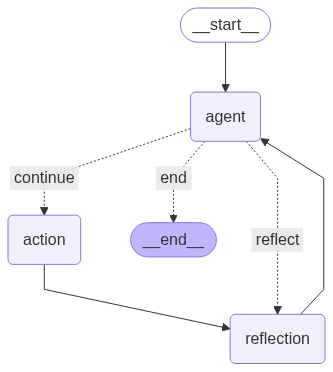

In [4]:
from IPython.display import Image, display

display(Image(chatbot_instance.graph.get_graph().draw_mermaid_png()))